In [ ]:
import pandas as pd

# Load the A-Level results data from the CSV file
df = pd.read_csv('/content/AL.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

# Display general information about the DataFrame
print(df.info())

# Display descriptive statistics of the DataFrame
display(df.describe())

,index,stream,Zscore,district_rank,island_rank,al_year,sub1,sub1_r,sub2,sub2_r,sub3,sub3_r,cgt_r,ge_r,syllabus,birth_day,birth_month,birth_year,gender
0,0,ARTS,-.3550,4336 (NEW),64994 (NEW),2020,POLITICAL SCIENCE,S,DANCING(BHARATHA),C,TAMIL,S,056,S,new,31,May,2001,female
1,1,ARTS,-.2648,4154 (NEW),62338 (NEW),2020,POLITICAL SCIENCE,S,CARNATIC MUSIC,C,TAMIL,C,032,C,new,13,January,2002,female
2,2,COMMERCE,-.4760,6910 (NEW),37307 (NEW),2020,ECONOMICS,S,BUSINESS STUDIES,S,ACCOUNTING,S,050,S,new,16,August,2001,female
3,3,COMMERCE,-.1012,5678 (NEW),30449 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,S,034,S,new,16,August,2001,female
4,4,COMMERCE,.6014,3269 (NEW),17010 (NEW),2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,B,036,S,new,7,August,2000,female


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 337553 entries, 0 to 337552
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   index          337553 non-null  int64 
 1   stream         337553 non-null  object
 2   Zscore         337553 non-null  object
 3   district_rank  337553 non-null  object
 4   island_rank    337553 non-null  object
 5   al_year        337553 non-null  int64 
 6   sub1           337553 non-null  object
 7   sub1_r         337553 non-null  object
 8   sub2           337553 non-null  object
 9   sub2_r         337553 non-null  object
 10  sub3           337553 non-null  object
 11  sub3_r         337553 non-null  object
 12  cgt_r          337553 non-null  object
 13  ge_r           337553 non-null  object
 14  syllabus       337553 non-null  object
 15  birth_day      337553 non-null  object
 16  birth_month    337553 non-null  object
 17  birth_year     337553 non-null  object
 18  gend

,index,al_year
count,337553.000000,337553.0
mean,168776.000000,2020.0
std,97443.302045,0.0
min,0.000000,2020.0
25%,84388.000000,2020.0
50%,168776.000000,2020.0
75%,253164.000000,2020.0
max,337552.000000,2020.0


In [ ]:
# Function to clean and convert columns to numeric
def clean_and_convert_numeric(df, columns):
    for col in columns:
        # Remove non-numeric characters (like '(NEW)' or extra spaces) from the column
        df[col] = df[col].astype(str).str.replace(r'[^\d.-]+', '', regex=True)
        # Convert to numeric, coercing errors to NaN
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

# Columns to clean and convert
numeric_cols = ['Zscore', 'district_rank', 'island_rank']
df = clean_and_convert_numeric(df, numeric_cols)

# Display the info and head of the DataFrame to confirm changes
print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 337553 entries, 0 to 337552
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   index          337553 non-null  int64  
 1   stream         337553 non-null  object 
 2   Zscore         232304 non-null  float64
 3   district_rank  184299 non-null  float64
 4   island_rank    184299 non-null  float64
 5   al_year        337553 non-null  int64  
 6   sub1           337553 non-null  object 
 7   sub1_r         337553 non-null  object 
 8   sub2           337553 non-null  object 
 9   sub2_r         337553 non-null  object 
 10  sub3           337553 non-null  object 
 11  sub3_r         337553 non-null  object 
 12  cgt_r          337553 non-null  object 
 13  ge_r           337553 non-null  object 
 14  syllabus       337553 non-null  object 
 15  birth_day      337553 non-null  object 
 16  birth_month    337553 non-null  object 
 17  birth_year     337553 non-nul

,index,stream,Zscore,district_rank,island_rank,al_year,sub1,sub1_r,sub2,sub2_r,sub3,sub3_r,cgt_r,ge_r,syllabus,birth_day,birth_month,birth_year,gender
0,0,ARTS,-0.3550,4336.0,64994.0,2020,POLITICAL SCIENCE,S,DANCING(BHARATHA),C,TAMIL,S,056,S,new,31,May,2001,female
1,1,ARTS,-0.2648,4154.0,62338.0,2020,POLITICAL SCIENCE,S,CARNATIC MUSIC,C,TAMIL,C,032,C,new,13,January,2002,female
2,2,COMMERCE,-0.4760,6910.0,37307.0,2020,ECONOMICS,S,BUSINESS STUDIES,S,ACCOUNTING,S,050,S,new,16,August,2001,female
3,3,COMMERCE,-0.1012,5678.0,30449.0,2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,S,034,S,new,16,August,2001,female
4,4,COMMERCE,0.6014,3269.0,17010.0,2020,ECONOMICS,C,BUSINESS STUDIES,C,ACCOUNTING,B,036,S,new,7,August,2000,female


In [ ]:
# Impute missing values in 'Zscore', 'district_rank', and 'island_rank' with their respective means
df['Zscore'] = df['Zscore'].fillna(df['Zscore'].mean())
df['district_rank'] = df['district_rank'].fillna(df['district_rank'].mean())
df['island_rank'] = df['island_rank'].fillna(df['island_rank'].mean())

# Impute missing values in 'gender' with its mode
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

# Display the info of the DataFrame to confirm changes in null counts and data types
print(df.info())

# Calculate the average Z-score for each stream
stream_performance = df.groupby('stream')['Zscore'].mean().sort_values(ascending=False)

print("\nAverage Z-score per Stream:")
display(stream_performance)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 337553 entries, 0 to 337552
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   index          337553 non-null  int64  
 1   stream         337553 non-null  object 
 2   Zscore         337553 non-null  float64
 3   district_rank  337553 non-null  float64
 4   island_rank    337553 non-null  float64
 5   al_year        337553 non-null  int64  
 6   sub1           337553 non-null  object 
 7   sub1_r         337553 non-null  object 
 8   sub2           337553 non-null  object 
 9   sub2_r         337553 non-null  object 
 10  sub3           337553 non-null  object 
 11  sub3_r         337553 non-null  object 
 12  cgt_r          337553 non-null  object 
 13  ge_r           337553 non-null  object 
 14  syllabus       337553 non-null  object 
 15  birth_day      337553 non-null  object 
 16  birth_month    337553 non-null  object 
 17  birth_year     337553 non-nul

,Zscore
stream,
PHYSICAL SCIENCE,0.638012
BIOLOGICAL SCIENCE,0.605590
COMMERCE,0.496741
BIOSYSTEMS TECHNOLOGY,0.487498
ARTS,0.471465
NON,0.466190
ENGINEERING TECHNOLOGY,0.463578
-,0.045173


In [ ]:
# Calculate the average Z-score for each district
district_performance = df.groupby('district_rank')['Zscore'].mean().sort_values(ascending=False)

print("\nTop 10 Districts by Average Z-score:")
display(district_performance.head(10))


Top 10 Districts by Average Z-score:


,Zscore
district_rank,
1.0,2.192567
2.0,1.979575
3.0,1.925183
4.0,1.817384
5.0,1.748989
6.0,1.692412
7.0,1.668389
8.0,1.657014
9.0,1.621706


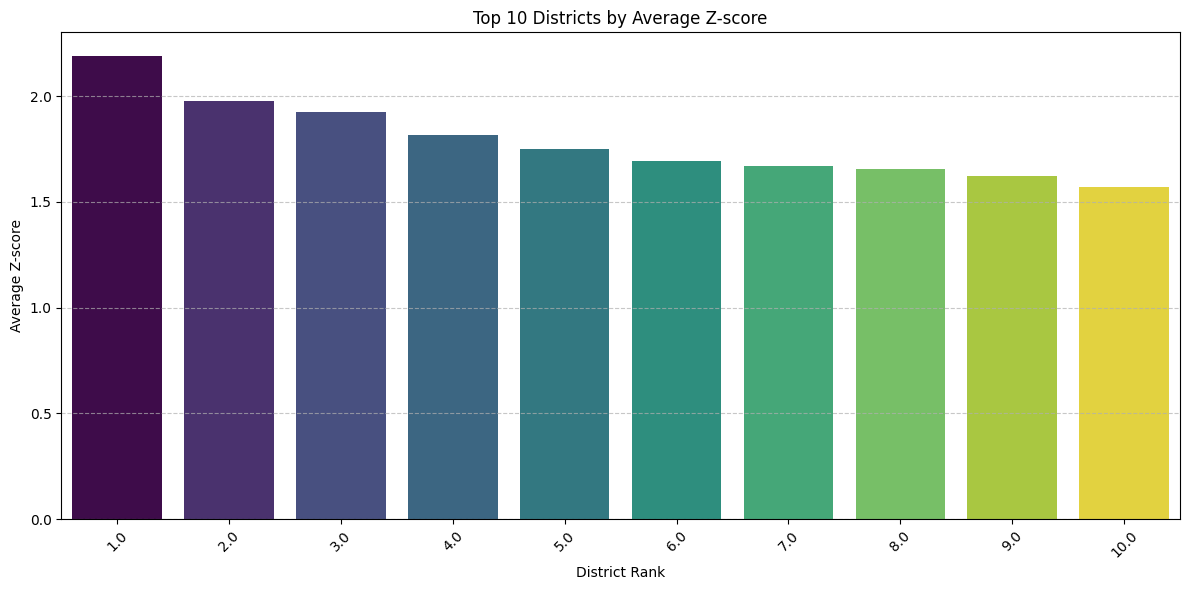

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the top 10 districts by average Z-score
plt.figure(figsize=(12, 6))
sns.barplot(x=district_performance.head(10).index, y=district_performance.head(10).values, hue=district_performance.head(10).index, palette='viridis', legend=False)
plt.title('Top 10 Districts by Average Z-score')
plt.xlabel('District Rank')
plt.ylabel('Average Z-score')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [1]:
# ============================================
# STEP 1: DEFINE BUSINESS REQUIREMENTS
# OLAP Cube - A/L Student Dataset
# ============================================

print("=" * 60)
print("OLAP CUBE - BUSINESS REQUIREMENTS")
print("=" * 60)

# Business questions that our OLAP cube should answer
business_questions = [
    "1. How many students are in each A/L stream?",
    "2. How many students are there by gender?",
    "3. How does student performance differ by stream and gender?",
    "4. How does performance differ between new and old syllabus?",
    "5. Which stream has the highest average Z-score?",
    "6. What are the most common grades for each subject?",
    "7. Can we analyze student performance at different levels of detail?"
]

print("\nBusiness Questions:")
for question in business_questions:
    print(question)

# Dimensions we plan to use
dimensions = [
    "Stream",
    "Gender",
    "Syllabus",
    "Subject",
    "Grade",
    "Year"
]

print("\nDimensions:")
for dimension in dimensions:
    print("-", dimension)

# Measures we plan to analyze
measures = [
    "Student Count",
    "Average Z-score",
    "Average District Rank",
    "Average Island Rank"
]

print("\nMeasures:")
for measure in measures:
    print("-", measure)

# Identify additive and non-additive measures
print("\nMeasure Classification:")

print("\nAdditive Measure:")
print("- Student Count")
print("  Can be summed across dimensions.")

print("\nNon-Additive Measures:")
print("- Average Z-score")
print("- Average District Rank")
print("- Average Island Rank")
print("  These should not be summed directly.")

print("\n" + "=" * 60)
print("BUSINESS REQUIREMENTS DEFINED")
print("=" * 60)

OLAP CUBE - BUSINESS REQUIREMENTS

Business Questions:
1. How many students are in each A/L stream?
2. How many students are there by gender?
3. How does student performance differ by stream and gender?
4. How does performance differ between new and old syllabus?
5. Which stream has the highest average Z-score?
6. What are the most common grades for each subject?
7. Can we analyze student performance at different levels of detail?

Dimensions:
- Stream
- Gender
- Syllabus
- Subject
- Grade
- Year

Measures:
- Student Count
- Average Z-score
- Average District Rank
- Average Island Rank

Measure Classification:

Additive Measure:
- Student Count
  Can be summed across dimensions.

Non-Additive Measures:
- Average Z-score
- Average District Rank
- Average Island Rank
  These should not be summed directly.

BUSINESS REQUIREMENTS DEFINED


In [10]:
# ============================================
# STEP 2: IDENTIFY THE DATA SOURCE
# OLAP Cube - A/L Student Dataset
# ============================================

import pandas as pd
import os

# --------------------------------------------
# 1. Load the dataset
# --------------------------------------------

file_path = "/content/AL.csv"

# Check if the file exists before attempting to read it
if not os.path.exists(file_path):
    print(f"Error: The file '{file_path}' was not found.")
    print("Please ensure the CSV file 'AL.csv' is uploaded to the /content/ directory.")
else:
    df = pd.read_csv(file_path)

    # --------------------------------------------
    # 2. Display basic information
    # --------------------------------------------

    print("=" * 60)
    print("DATA SOURCE INFORMATION")
    print("=" * 60)

    print("\nFile:")
    print(file_path)

    print("\nNumber of rows:")
    print(df.shape[0])

    print("\nNumber of columns:")
    print(df.shape[1])

    # --------------------------------------------
    # 3. Display column names
    # --------------------------------------------

    print("\nColumns in the dataset:")

    for column in df.columns:
        print("-", column)

    # --------------------------------------------
    # 4. Display first 5 records
    # --------------------------------------------

    print("\nFirst 5 records:")
    print(df.head())

    # --------------------------------------------
    # 5. Display data types
    # --------------------------------------------

    print("\nData types:")
    print(df.dtypes)

    # --------------------------------------------
    # 6. Check missing values
    # --------------------------------------------

    print("\nMissing values:")

    missing_values = df.isnull().sum()

    print(missing_values)

    # --------------------------------------------
    # 7. Display unique values for important fields
    # --------------------------------------------

    print("\nUnique Streams:")
    print(df["stream"].unique())

    print("\nUnique Genders:")
    print(df["gender"].unique())

    print("\nUnique Syllabus Types:")
    print(df["syllabus"].unique())

    print("\nUnique A/L Years:")
    print(df["al_year"].unique())

    # --------------------------------------------
    # 8. Final summary
    # --------------------------------------------

    print("\n" + "=" * 60)
    print("DATA SOURCE IDENTIFIED SUCCESSFULLY")
    print("=" * 60)

    print(f"Total records: {len(df):,}")
    print(f"Total columns: {len(df.columns)}")

DATA SOURCE INFORMATION

File:
/content/AL.csv

Number of rows:
275217

Number of columns:
19

Columns in the dataset:
- index
- stream
- Zscore
- district_rank
- island_rank
- al_year
- sub1
- sub1_r
- sub2
- sub2_r
- sub3
- sub3_r
- cgt_r
- ge_r
- syllabus
- birth_day
- birth_month
- birth_year
- gender

First 5 records:
   index    stream  Zscore district_rank  island_rank  al_year  \
0      0      ARTS  -.3550    4336 (NEW)  64994 (NEW)     2020   
1      1      ARTS  -.2648    4154 (NEW)  62338 (NEW)     2020   
2      2  COMMERCE  -.4760    6910 (NEW)  37307 (NEW)     2020   
3      3  COMMERCE  -.1012    5678 (NEW)  30449 (NEW)     2020   
4      4  COMMERCE   .6014    3269 (NEW)  17010 (NEW)     2020   

                sub1 sub1_r               sub2 sub2_r        sub3 sub3_r  \
0  POLITICAL SCIENCE      S  DANCING(BHARATHA)      C       TAMIL      S   
1  POLITICAL SCIENCE      S     CARNATIC MUSIC      C       TAMIL      C   
2          ECONOMICS      S   BUSINESS STUDIES    

In [11]:
# ============================================
# STEP 3: DEFINE DIMENSIONS AND HIERARCHIES
# OLAP Cube - A/L Student Dataset
# ============================================

import pandas as pd

# --------------------------------------------
# 1. Load the dataset
# --------------------------------------------

file_path = "AL.csv"
df = pd.read_csv(file_path)

print("=" * 60)
print("OLAP DIMENSIONS AND HIERARCHIES")
print("=" * 60)

# --------------------------------------------
# 2. Define dimensions
# --------------------------------------------

dimensions = {
    "Time": ["al_year"],

    "Stream": ["stream"],

    "Gender": ["gender"],

    "Syllabus": ["syllabus"],

    "Subject": [
        "sub1",
        "sub2",
        "sub3"
    ]
}

# --------------------------------------------
# 3. Display dimensions
# --------------------------------------------

print("\nDimensions:")

for dimension, attributes in dimensions.items():

    print(f"\n{dimension}:")

    for attribute in attributes:
        print(f"  - {attribute}")

# --------------------------------------------
# 4. Define hierarchies
# --------------------------------------------

hierarchies = {

    "Time Hierarchy": [
        "Year"
    ],

    "Subject Hierarchy": [
        "Subject",
        "Grade"
    ],

    "Performance Hierarchy": [
        "Stream",
        "Subject",
        "Grade"
    ]
}

# --------------------------------------------
# 5. Display hierarchies
# --------------------------------------------

print("\n" + "=" * 60)
print("HIERARCHIES")
print("=" * 60)

for hierarchy, levels in hierarchies.items():

    print(f"\n{hierarchy}")

    for i, level in enumerate(levels):

        if i < len(levels) - 1:
            print(f"  {level} -> ", end="")
        else:
            print(level)

# --------------------------------------------
# 6. Show unique dimension values
# --------------------------------------------

print("\n" + "=" * 60)
print("DIMENSION VALUES")
print("=" * 60)

print("\nYears:")
print(df["al_year"].unique())

print("\nStreams:")
print(df["stream"].unique())

print("\nGenders:")
print(df["gender"].unique())

print("\nSyllabus:")
print(df["syllabus"].unique())

# --------------------------------------------
# 7. Show number of values
# --------------------------------------------

print("\n" + "=" * 60)
print("NUMBER OF DIMENSION MEMBERS")
print("=" * 60)

print("Number of years:",
      df["al_year"].nunique())

print("Number of streams:",
      df["stream"].nunique())

print("Number of genders:",
      df["gender"].nunique())

print("Number of syllabus types:",
      df["syllabus"].nunique())

print("\n" + "=" * 60)
print("DIMENSIONS AND HIERARCHIES DEFINED")
print("=" * 60)

OLAP DIMENSIONS AND HIERARCHIES

Dimensions:

Time:
  - al_year

Stream:
  - stream

Gender:
  - gender

Syllabus:
  - syllabus

Subject:
  - sub1
  - sub2
  - sub3

HIERARCHIES

Time Hierarchy
Year

Subject Hierarchy
  Subject -> Grade

Performance Hierarchy
  Stream ->   Subject -> Grade

DIMENSION VALUES

Years:
[2020]

Streams:
['ARTS' 'COMMERCE' '-' 'NON' 'PHYSICAL SCIENCE' 'BIOLOGICAL SCIENCE'
 'ENGINEERING TECHNOLOGY' 'BIOSYSTEMS TECHNOLOGY']

Genders:
['female' 'male' nan 'Major error']

Syllabus:
['new' 'old']

NUMBER OF DIMENSION MEMBERS
Number of years: 1
Number of streams: 8
Number of genders: 3
Number of syllabus types: 2

DIMENSIONS AND HIERARCHIES DEFINED


In [12]:
# ============================================
# STEP 4: CHOOSE FACTS / MEASURES
# OLAP Cube - A/L Student Dataset
# ============================================

import pandas as pd

# --------------------------------------------
# 1. Load dataset
# --------------------------------------------

file_path = "AL.csv"

df = pd.read_csv(file_path)

print("=" * 60)
print("FACTS AND MEASURES")
print("=" * 60)

# --------------------------------------------
# 2. Convert numeric fields
# --------------------------------------------

# Convert Z-score to numeric
df["Zscore"] = pd.to_numeric(
    df["Zscore"],
    errors="coerce"
)

# Convert district rank to numeric
df["district_rank"] = pd.to_numeric(
    df["district_rank"]
        .astype(str)
        .str.extract(r"(\d+)")[0],
    errors="coerce"
)

# Convert island rank to numeric
df["island_rank"] = pd.to_numeric(
    df["island_rank"]
        .astype(str)
        .str.extract(r"(\d+)")[0],
    errors="coerce"
)

# --------------------------------------------
# 3. Define measures
# --------------------------------------------

measures = {
    "Student_Count": {
        "type": "Additive",
        "description": "Number of student records"
    },

    "Average_Zscore": {
        "type": "Non-Additive",
        "description": "Average student Z-score"
    },

    "Average_District_Rank": {
        "type": "Non-Additive",
        "description": "Average district rank"
    },

    "Average_Island_Rank": {
        "type": "Non-Additive",
        "description": "Average island rank"
    }
}

# --------------------------------------------
# 4. Display measures
# --------------------------------------------

print("\nMeasures:")

for measure, information in measures.items():

    print(f"\n{measure}")
    print("Type:", information["type"])
    print("Description:", information["description"])

# --------------------------------------------
# 5. Calculate overall measures
# --------------------------------------------

student_count = len(df)

average_zscore = df["Zscore"].mean()

average_district_rank = df["district_rank"].mean()

average_island_rank = df["island_rank"].mean()

print("\n" + "=" * 60)
print("OVERALL MEASURE VALUES")
print("=" * 60)

print(f"\nStudent Count: {student_count:,}")

print(
    f"Average Z-score: {average_zscore:.3f}"
)

print(
    f"Average District Rank: {average_district_rank:.2f}"
)

print(
    f"Average Island Rank: {average_island_rank:.2f}"
)

# --------------------------------------------
# 6. Demonstrate additive measure
# --------------------------------------------

print("\n" + "=" * 60)
print("ADDITIVE MEASURE")
print("=" * 60)

print(
    "Student Count is additive because "
    "student counts can be summed across dimensions."
)

stream_counts = df.groupby("stream").size()

print("\nStudent count by stream:")
print(stream_counts)

print(
    "\nTotal from stream counts:",
    f"{stream_counts.sum():,}"
)

# --------------------------------------------
# 7. Demonstrate non-additive measures
# --------------------------------------------

print("\n" + "=" * 60)
print("NON-ADDITIVE MEASURES")
print("=" * 60)

print(
    "Average Z-score, District Rank and Island Rank "
    "must NOT be summed."
)

print(
    "\nThey should be recalculated when we "
    "change the OLAP level of analysis."
)

# --------------------------------------------
# 8. Create measure summary
# --------------------------------------------

measure_summary = pd.DataFrame({
    "Measure": [
        "Student Count",
        "Average Z-score",
        "Average District Rank",
        "Average Island Rank"
    ],

    "Type": [
        "Additive",
        "Non-Additive",
        "Non-Additive",
        "Non-Additive"
    ],

    "Overall_Value": [
        student_count,
        round(average_zscore, 3),
        round(average_district_rank, 2),
        round(average_island_rank, 2)
    ]
})

print("\nMeasure Summary:")
print(measure_summary)

# --------------------------------------------
# 9. Save measures to CSV
# --------------------------------------------

measure_summary.to_csv(
    "measure_summary.csv",
    index=False
)

print("\n" + "=" * 60)
print("FACTS / MEASURES DEFINED SUCCESSFULLY")
print("=" * 60)

FACTS AND MEASURES

Measures:

Student_Count
Type: Additive
Description: Number of student records

Average_Zscore
Type: Non-Additive
Description: Average student Z-score

Average_District_Rank
Type: Non-Additive
Description: Average district rank

Average_Island_Rank
Type: Non-Additive
Description: Average island rank

OVERALL MEASURE VALUES

Student Count: 337,553
Average Z-score: 0.305
Average District Rank: 1304.36
Average Island Rank: 21584.62

ADDITIVE MEASURE
Student Count is additive because student counts can be summed across dimensions.

Student count by stream:
stream
-                         150514
ARTS                       76547
BIOLOGICAL SCIENCE         25768
BIOSYSTEMS TECHNOLOGY       7833
COMMERCE                   39877
ENGINEERING TECHNOLOGY     12498
NON                         2740
PHYSICAL SCIENCE           21776
dtype: int64

Total from stream counts: 337,553

NON-ADDITIVE MEASURES
Average Z-score, District Rank and Island Rank must NOT be summed.

They should

In [13]:
# ============================================
# STEP 5: BUILD AND POPULATE OLAP CUBE
# OLAP Cube - A/L Student Dataset
# ============================================

import pandas as pd
import numpy as np

# --------------------------------------------
# 1. LOAD DATASET
# --------------------------------------------

file_path = "AL.csv"

df = pd.read_csv(file_path)

print("=" * 70)
print("BUILDING OLAP CUBE")
print("=" * 70)

print("\nTotal records:", len(df))


# --------------------------------------------
# 2. CLEAN NUMERIC MEASURES
# --------------------------------------------

# Z-score
df["Zscore_num"] = pd.to_numeric(
    df["Zscore"],
    errors="coerce"
)

# District rank
df["district_rank_num"] = pd.to_numeric(
    df["district_rank"]
        .astype(str)
        .str.extract(r"(\d+)")[0],
    errors="coerce"
)

# Island rank
df["island_rank_num"] = pd.to_numeric(
    df["island_rank"]
        .astype(str)
        .str.extract(r"(\d+)")[0],
    errors="coerce"
)


# --------------------------------------------
# 3. CLEAN DIMENSIONS
# --------------------------------------------

for column in ["stream", "gender", "syllabus"]:

    df[column] = (
        df[column]
        .fillna("Unknown")
        .astype(str)
        .str.strip()
        .str.upper()
    )


# --------------------------------------------
# 4. BUILD THE MAIN OLAP CUBE
# --------------------------------------------

# Dimensions:
# Stream × Gender × Syllabus

cube = (
    df
    .groupby(
        ["stream", "gender", "syllabus"],
        dropna=False
    )
    .agg(
        Student_Count=("index", "count"),

        Avg_Zscore=(
            "Zscore_num",
            "mean"
        ),

        Avg_District_Rank=(
            "district_rank_num",
            "mean"
        ),

        Avg_Island_Rank=(
            "island_rank_num",
            "mean"
        )
    )
    .reset_index()
)


# --------------------------------------------
# 5. DISPLAY THE CUBE
# --------------------------------------------

print("\n" + "=" * 70)
print("MAIN OLAP CUBE")
print("=" * 70)

print(cube.to_string(index=False))


# --------------------------------------------
# 6. ROLL-UP
# --------------------------------------------

# Roll-up from:
#
# Stream + Gender + Syllabus
#
# to:
#
# Stream

print("\n" + "=" * 70)
print("ROLL-UP: STREAM LEVEL")
print("=" * 70)

rollup_stream = (
    df
    .groupby("stream")
    .agg(
        Student_Count=("index", "count"),

        Avg_Zscore=(
            "Zscore_num",
            "mean"
        ),

        Avg_District_Rank=(
            "district_rank_num",
            "mean"
        ),

        Avg_Island_Rank=(
            "island_rank_num",
            "mean"
        )
    )
    .reset_index()
    .sort_values(
        "Avg_Zscore",
        ascending=False
    )
)

print(rollup_stream.to_string(index=False))


# --------------------------------------------
# 7. ROLL-UP BY GENDER
# --------------------------------------------

print("\n" + "=" * 70)
print("ROLL-UP: GENDER LEVEL")
print("=" * 70)

rollup_gender = (
    df
    .groupby("gender")
    .agg(
        Student_Count=("index", "count"),

        Avg_Zscore=(
            "Zscore_num",
            "mean"
        )
    )
    .reset_index()
)

print(rollup_gender.to_string(index=False))


# --------------------------------------------
# 8. SLICE
# --------------------------------------------

# Slice the cube:
#
# Gender = FEMALE

print("\n" + "=" * 70)
print("SLICE: FEMALE STUDENTS")
print("=" * 70)

female_slice = (
    df[
        df["gender"] == "FEMALE"
    ]
    .groupby(
        ["stream", "syllabus"]
    )
    .agg(
        Student_Count=("index", "count"),

        Avg_Zscore=(
            "Zscore_num",
            "mean"
        )
    )
    .reset_index()
)

print(female_slice.to_string(index=False))


# --------------------------------------------
# 9. DICE
# --------------------------------------------

# Dice operation:
#
# Stream = ARTS or COMMERCE
# Syllabus = NEW or OLD

print("\n" + "=" * 70)
print("DICE: ARTS + COMMERCE")
print("=" * 70)

dice = (
    df[
        df["stream"].isin(
            ["ARTS", "COMMERCE"]
        )
        &
        df["syllabus"].isin(
            ["NEW", "OLD"]
        )
    ]
    .groupby(
        ["stream", "gender", "syllabus"]
    )
    .agg(
        Student_Count=("index", "count"),

        Avg_Zscore=(
            "Zscore_num",
            "mean"
        )
    )
    .reset_index()
)

print(dice.to_string(index=False))


# --------------------------------------------
# 10. DRILL-DOWN
# --------------------------------------------

# Drill-down hierarchy:
#
# Stream
#    ↓
# Subject
#    ↓
# Grade
#
# We use Subject 1 as an example.

print("\n" + "=" * 70)
print("DRILL-DOWN: STREAM → SUBJECT → GRADE")
print("=" * 70)

drilldown = (
    df
    .groupby(
        ["stream", "sub1", "sub1_r"]
    )
    .size()
    .reset_index(
        name="Student_Count"
    )
    .sort_values(
        ["stream", "Student_Count"],
        ascending=[True, False]
    )
)

print(
    drilldown.head(50)
    .to_string(index=False)
)


# --------------------------------------------
# 11. SAVE ALL OLAP RESULTS
# --------------------------------------------

cube.to_csv(
    "olap_cube.csv",
    index=False
)

rollup_stream.to_csv(
    "rollup_stream.csv",
    index=False
)

rollup_gender.to_csv(
    "rollup_gender.csv",
    index=False
)

female_slice.to_csv(
    "slice_female.csv",
    index=False
)

dice.to_csv(
    "dice_arts_commerce.csv",
    index=False
)

drilldown.to_csv(
    "drilldown_subject_grade.csv",
    index=False
)


# --------------------------------------------
# 12. FINAL SUMMARY
# --------------------------------------------

print("\n" + "=" * 70)
print("OLAP CUBE CREATED SUCCESSFULLY")
print("=" * 70)

print("\nMain cube dimensions:")
print("Stream × Gender × Syllabus")

print("\nMeasures:")
print("- Student Count")
print("- Average Z-score")
print("- Average District Rank")
print("- Average Island Rank")

print("\nOLAP operations completed:")
print("- Roll-up")
print("- Slice")
print("- Dice")
print("- Drill-down")

print("\nOutput files created:")
print("- olap_cube.csv")
print("- rollup_stream.csv")
print("- rollup_gender.csv")
print("- slice_female.csv")
print("- dice_arts_commerce.csv")
print("- drilldown_subject_grade.csv")

print("\n" + "=" * 70)

BUILDING OLAP CUBE

Total records: 337553

MAIN OLAP CUBE
                stream      gender syllabus  Student_Count  Avg_Zscore  Avg_District_Rank  Avg_Island_Rank
                     -      FEMALE      NEW          62299   -0.526066                NaN              NaN
                     -      FEMALE      OLD          10078   -0.556775                NaN              NaN
                     - MAJOR ERROR      NEW             13   -0.890533                NaN              NaN
                     - MAJOR ERROR      OLD              3   -0.798400                NaN              NaN
                     -        MALE      NEW          68858   -0.596542                NaN              NaN
                     -        MALE      OLD           8060   -0.532630                NaN              NaN
                     -     UNKNOWN      NEW            613   -0.691515                NaN              NaN
                     -     UNKNOWN      OLD            590   -0.618122                

In [14]:
# ============================================
# STEP 6: VALIDATE AND TEST OLAP CUBE
# OLAP Cube - A/L Student Dataset
# ============================================

import pandas as pd

# --------------------------------------------
# 1. LOAD ORIGINAL DATA
# --------------------------------------------

df = pd.read_csv("AL.csv")

print("=" * 70)
print("OLAP CUBE VALIDATION AND TESTING")
print("=" * 70)


# --------------------------------------------
# 2. LOAD THE OLAP CUBE
# --------------------------------------------

cube = pd.read_csv("olap_cube.csv")


# --------------------------------------------
# TEST 1: RECORD COUNT VALIDATION
# --------------------------------------------

print("\n" + "=" * 70)
print("TEST 1: RECORD COUNT VALIDATION")
print("=" * 70)

source_count = len(df)

cube_count = cube["Student_Count"].sum()

print("Original dataset records:", f"{source_count:,}")
print("Cube records:", f"{cube_count:,.0f}")

if source_count == cube_count:
    print("RESULT: PASS")
    print("Cube total matches the original dataset.")
else:
    print("RESULT: FAIL")
    print("Cube total does not match the original dataset.")


# --------------------------------------------
# TEST 2: DIMENSION VALIDATION
# --------------------------------------------

print("\n" + "=" * 70)
print("TEST 2: DIMENSION VALIDATION")
print("=" * 70)

source_streams = set(
    df["stream"].dropna().astype(str).str.strip().str.upper()
)

cube_streams = set(
    cube["stream"].dropna().astype(str).str.strip().str.upper()
)

print("Source streams:")
print(source_streams)

print("\nCube streams:")
print(cube_streams)

if source_streams == cube_streams:
    print("\nRESULT: PASS")
else:
    print("\nRESULT: FAIL")


# --------------------------------------------
# TEST 3: GENDER VALIDATION
# --------------------------------------------

print("\n" + "=" * 70)
print("TEST 3: GENDER VALIDATION")
print("=" * 70)

source_genders = set(
    df["gender"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .str.upper()
)

cube_genders = set(
    cube["gender"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .str.upper()
)

print("Source genders:")
print(source_genders)

print("\nCube genders:")
print(cube_genders)

if source_genders == cube_genders:
    print("\nRESULT: PASS")
else:
    print("\nRESULT: FAIL")


# --------------------------------------------
# TEST 4: SYLLABUS VALIDATION
# --------------------------------------------

print("\n" + "=" * 70)
print("TEST 4: SYLLABUS VALIDATION")
print("=" * 70)

source_syllabus = set(
    df["syllabus"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .str.upper()
)

cube_syllabus = set(
    cube["syllabus"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .str.upper()
)

print("Source syllabus:")
print(source_syllabus)

print("\nCube syllabus:")
print(cube_syllabus)

if source_syllabus == cube_syllabus:
    print("\nRESULT: PASS")
else:
    print("\nRESULT: FAIL")


# --------------------------------------------
# TEST 5: ROLL-UP VALIDATION
# --------------------------------------------

print("\n" + "=" * 70)
print("TEST 5: ROLL-UP VALIDATION")
print("=" * 70)

rollup_stream = pd.read_csv(
    "rollup_stream.csv"
)

rollup_total = rollup_stream[
    "Student_Count"
].sum()

print(
    "Cube total:",
    f"{cube_count:,.0f}"
)

print(
    "Roll-up total:",
    f"{rollup_total:,.0f}"
)

if cube_count == rollup_total:
    print("\nRESULT: PASS")
    print("Roll-up preserves the total student count.")
else:
    print("\nRESULT: FAIL")


# --------------------------------------------
# TEST 6: SLICE VALIDATION
# --------------------------------------------

print("\n" + "=" * 70)
print("TEST 6: SLICE VALIDATION")
print("=" * 70)

female_slice = pd.read_csv(
    "slice_female.csv"
)

female_source_count = len(
    df[
        df["gender"]
        .fillna("Unknown")
        .astype(str)
        .str.strip()
        .str.upper()
        == "FEMALE"
    ]
)

female_slice_count = female_slice[
    "Student_Count"
].sum()

print(
    "Female records in source:",
    f"{female_source_count:,}"
)

print(
    "Female records in slice:",
    f"{female_slice_count:,.0f}"
)

if female_source_count == female_slice_count:
    print("\nRESULT: PASS")
    print("Female slice is correct.")
else:
    print("\nRESULT: FAIL")


# --------------------------------------------
# TEST 7: DICE VALIDATION
# --------------------------------------------

print("\n" + "=" * 70)
print("TEST 7: DICE VALIDATION")
print("=" * 70)

dice = pd.read_csv(
    "dice_arts_commerce.csv"
)

dice_source_count = len(
    df[
        df["stream"]
        .fillna("Unknown")
        .astype(str)
        .str.strip()
        .str.upper()
        .isin(["ARTS", "COMMERCE"])
        &
        df["syllabus"]
        .fillna("Unknown")
        .astype(str)
        .str.strip()
        .str.upper()
        .isin(["NEW", "OLD"])
    ]
)

dice_count = dice[
    "Student_Count"
].sum()

print(
    "Matching records in source:",
    f"{dice_source_count:,}"
)

print(
    "Records in dice:",
    f"{dice_count:,.0f}"
)

if dice_source_count == dice_count:
    print("\nRESULT: PASS")
    print("Dice operation is correct.")
else:
    print("\nRESULT: FAIL")


# --------------------------------------------
# TEST 8: CHECK FOR NEGATIVE COUNTS
# --------------------------------------------

print("\n" + "=" * 70)
print("TEST 8: CHECK STUDENT COUNTS")
print("=" * 70)

negative_counts = (
    cube["Student_Count"] < 0
).sum()

print(
    "Negative student counts:",
    negative_counts
)

if negative_counts == 0:
    print("RESULT: PASS")
else:
    print("RESULT: FAIL")


# --------------------------------------------
# TEST 9: CHECK Z-SCORE VALUES
# --------------------------------------------

print("\n" + "=" * 70)
print("TEST 9: CHECK AVERAGE Z-SCORES")
print("=" * 70)

invalid_zscores = (
    cube["Avg_Zscore"]
    .dropna()
    .apply(lambda x: not isinstance(x, (int, float)))
    .sum()
)

print(
    "Invalid average Z-score values:",
    invalid_zscores
)

if invalid_zscores == 0:
    print("RESULT: PASS")
else:
    print("RESULT: FAIL")


# --------------------------------------------
# TEST 10: DISPLAY FINAL CUBE
# --------------------------------------------

print("\n" + "=" * 70)
print("FINAL OLAP CUBE")
print("=" * 70)

print(
    cube.to_string(index=False)
)


# --------------------------------------------
# FINAL VALIDATION SUMMARY
# --------------------------------------------

print("\n" + "=" * 70)
print("FINAL VALIDATION SUMMARY")
print("=" * 70)

tests = {
    "Record Count": source_count == cube_count,
    "Stream Dimension": source_streams == cube_streams,
    "Gender Dimension": source_genders == cube_genders,
    "Syllabus Dimension": source_syllabus == cube_syllabus,
    "Roll-up": cube_count == rollup_total,
    "Slice": female_source_count == female_slice_count,
    "Dice": dice_source_count == dice_count,
    "Negative Counts": negative_counts == 0,
    "Z-score Values": invalid_zscores == 0
}

for test_name, result in tests.items():

    status = "PASS" if result else "FAIL"

    print(
        f"{test_name:<25} : {status}"
    )


# --------------------------------------------
# OVERALL RESULT
# --------------------------------------------

if all(tests.values()):

    print("\n" + "=" * 70)
    print("OVERALL RESULT: PASS")
    print("OLAP CUBE VALIDATED SUCCESSFULLY")
    print("=" * 70)

else:

    print("\n" + "=" * 70)
    print("OVERALL RESULT: CHECK REQUIRED")
    print("Some validation tests failed.")
    print("=" * 70)

OLAP CUBE VALIDATION AND TESTING

TEST 1: RECORD COUNT VALIDATION
Original dataset records: 337,553
Cube records: 337,553
RESULT: PASS
Cube total matches the original dataset.

TEST 2: DIMENSION VALIDATION
Source streams:
{'ARTS', '-', 'BIOLOGICAL SCIENCE', 'ENGINEERING TECHNOLOGY', 'NON', 'BIOSYSTEMS TECHNOLOGY', 'COMMERCE', 'PHYSICAL SCIENCE'}

Cube streams:
{'ARTS', '-', 'PHYSICAL SCIENCE', 'ENGINEERING TECHNOLOGY', 'NON', 'BIOSYSTEMS TECHNOLOGY', 'COMMERCE', 'BIOLOGICAL SCIENCE'}

RESULT: PASS

TEST 3: GENDER VALIDATION
Source genders:
{'UNKNOWN', 'FEMALE', 'MAJOR ERROR', 'MALE'}

Cube genders:
{'UNKNOWN', 'FEMALE', 'MAJOR ERROR', 'MALE'}

RESULT: PASS

TEST 4: SYLLABUS VALIDATION
Source syllabus:
{'NEW', 'OLD'}

Cube syllabus:
{'NEW', 'OLD'}

RESULT: PASS

TEST 5: ROLL-UP VALIDATION
Cube total: 337,553
Roll-up total: 337,553

RESULT: PASS
Roll-up preserves the total student count.

TEST 6: SLICE VALIDATION
Female records in source: 193,326
Female records in slice: 193,326

RESULT: